25% credible area = 442.3 deg^2
68% credible area = 1968.1 deg^2
95% credible area = 5588.9 deg^2


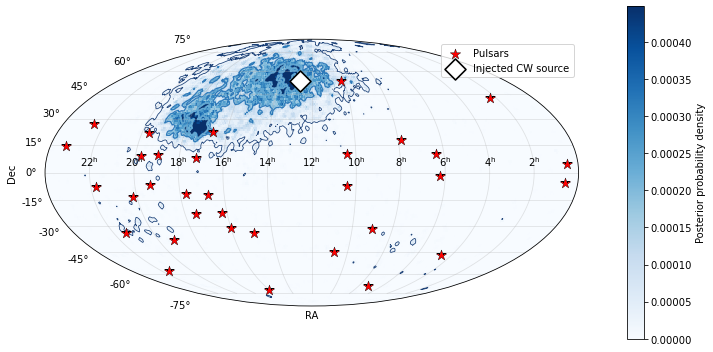

In [1]:
import numpy as np
import h5py
import json
import healpy as hp
import matplotlib.pyplot as plt

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
CORE_FILE   = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_allsky_outfile.h5"
PULSAR_JSON = "pulsar_positions.json"

NSIDE     = 64
THIN      = 1          # you can thin later if needed
FWHM_DEG  = 2.0
LEVELS    = (0.25, 0.68, 0.95)
BINS_RA   = 360
BINS_DEC  = 180

# -------------------------------------------------
# LOAD SAMPLES
# -------------------------------------------------
with h5py.File(CORE_FILE, "r") as f:
    samples = f["samples_cold"][0][::THIN]

# Physical sky coordinates
phi_phys  = samples[:, 2]                        # RA in [0, 2pi)
dec_phys  = np.pi/2 - np.arccos(samples[:, 0])   # Dec

# -------------------------------------------------
# BUILD HEALPIX POSTERIOR (PHYSICAL SKY)
# -------------------------------------------------
post_hp = np.zeros(hp.nside2npix(NSIDE))

theta = np.pi/2 - dec_phys
phi   = np.mod(phi_phys, 2*np.pi)

pix = hp.ang2pix(NSIDE, theta, phi)
np.add.at(post_hp, pix, 1)
post_hp /= post_hp.sum()

# Smooth
post_hp = hp.smoothing(
    post_hp,
    fwhm=np.radians(FWHM_DEG),
    verbose=False
)

# -------------------------------------------------
# HPD THRESHOLDS (ON THE SPHERE)
# -------------------------------------------------
idx = np.argsort(post_hp)[::-1]
cdf = np.cumsum(post_hp[idx])

levels_vals = []
pixarea = hp.nside2pixarea(NSIDE, degrees=True)

for lev in LEVELS:
    n = np.searchsorted(cdf, lev) + 1
    levels_vals.append(post_hp[idx][n-1])
    print(f"{int(lev*100)}% credible area = {n*pixarea:.1f} deg^2")

levels_vals = np.sort(levels_vals)

# -------------------------------------------------
# PROJECT TO RA–DEC GRID (PHYSICAL SKY FIRST)
# -------------------------------------------------
ra_cent_phys  = np.linspace(0, 2*np.pi, BINS_RA, endpoint=False)
dec_cent      = np.linspace(-np.pi/2, np.pi/2, BINS_DEC)

RA_phys, DEC = np.meshgrid(ra_cent_phys, dec_cent, indexing="ij")

theta_g = np.pi/2 - DEC
phi_g   = RA_phys                       # IMPORTANT: NO +pi HERE

pix_g = hp.ang2pix(NSIDE, theta_g, phi_g)
post_grid = post_hp[pix_g]

# -------------------------------------------------
# CONVERT RA ONLY FOR PLOTTING (ASTRONOMICAL CONVENTION)
# -------------------------------------------------
ra_plot = np.pi - ra_cent_phys           # RA increases to the left

# -------------------------------------------------
# LOAD PULSARS
# -------------------------------------------------
with open(PULSAR_JSON) as f:
    data = json.load(f)

ra_psr  = np.array([v[1][0] for v in data.values()])
dec_psr = np.array([v[1][1] for v in data.values()])

# -------------------------------------------------
# TRUE CW SOURCE (VERIFIED)
# -------------------------------------------------
gw_phi   = 3.3335788713091694
gw_theta = 0.6387905062299246
gw_dec   = np.pi/2 - gw_theta

# -------------------------------------------------
# COLOR SCALING
# -------------------------------------------------
vmax = np.percentile(post_grid, 99.5)

# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection="mollweide")

# Background posterior
pcm = ax.pcolormesh(
    ra_plot,
    dec_cent,
    post_grid.T,
    cmap="Blues",          # print-safe, monotonic
    shading="nearest",
    vmin=0,
    vmax=vmax
)


cb = plt.colorbar(pcm, ax=ax, fraction=0.04, pad=0.08)
cb.set_label("Posterior probability density")

# Credible regions
RA_plot, _ = np.meshgrid(ra_plot, dec_cent, indexing="ij")
ax.contour(
    RA_plot, DEC, post_grid,
    levels=levels_vals,
    colors=["#08306B", "#2171B5", "#6BAED6"],
    linewidths=[0.8, 1.2, 1.8],   # inner → outer
    alpha=0.9
)


# Pulsars
ax.scatter(
    np.pi - ra_psr,
    dec_psr,
    marker="*",
    s=120,
    color="red",
    edgecolor="k",
    linewidth=0.4,
    label="Pulsars",
    zorder=5
)

# CW source
ax.scatter(
    np.pi - gw_phi,
    gw_dec,
    marker="D",
    s=220,
    facecolor="white",
    edgecolor="black",
    linewidth=1.6,
    label="Injected CW source",
    zorder=10
)

# Formatting
ax.grid(True, alpha=0.35)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")

ax.set_xticklabels([
    r"$22^{\rm h}$", r"$20^{\rm h}$", r"$18^{\rm h}$",
    r"$16^{\rm h}$", r"$14^{\rm h}$", r"$12^{\rm h}$",
    r"$10^{\rm h}$", r"$8^{\rm h}$", r"$6^{\rm h}$",
    r"$4^{\rm h}$", r"$2^{\rm h}$"
])

ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
plt.show()


25% credible area = 442.3 deg^2
68% credible area = 1968.1 deg^2
95% credible area = 5588.9 deg^2


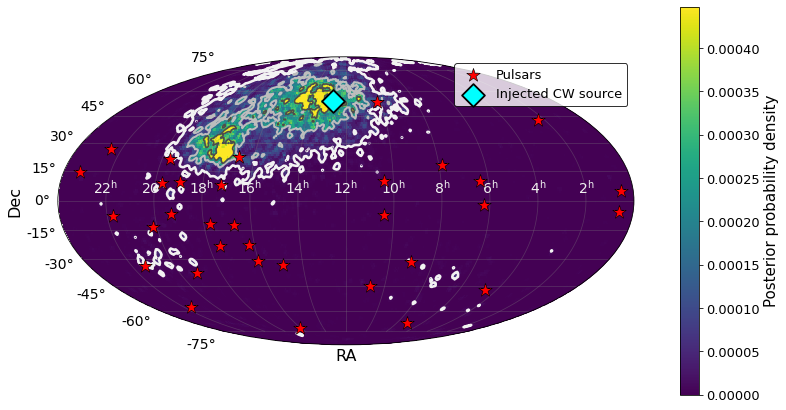

In [5]:
import numpy as np
import h5py
import json
import healpy as hp
import matplotlib.pyplot as plt

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
CORE_FILE   = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_allsky_outfile.h5"
PULSAR_JSON = "pulsar_positions.json"

NSIDE     = 64
THIN      = 1          # you can thin later if needed
FWHM_DEG  = 2.0
LEVELS    = (0.25, 0.68, 0.95)
BINS_RA   = 360
BINS_DEC  = 180

# -------------------------------------------------
# LOAD SAMPLES
# -------------------------------------------------
with h5py.File(CORE_FILE, "r") as f:
    samples = f["samples_cold"][0][::THIN]

# Physical sky coordinates
phi_phys  = samples[:, 2]                        # RA in [0, 2pi)
dec_phys  = np.pi/2 - np.arccos(samples[:, 0])   # Dec

# -------------------------------------------------
# BUILD HEALPIX POSTERIOR (PHYSICAL SKY)
# -------------------------------------------------
post_hp = np.zeros(hp.nside2npix(NSIDE))

theta = np.pi/2 - dec_phys
phi   = np.mod(phi_phys, 2*np.pi)

pix = hp.ang2pix(NSIDE, theta, phi)
np.add.at(post_hp, pix, 1)
post_hp /= post_hp.sum()

# Smooth
post_hp = hp.smoothing(
    post_hp,
    fwhm=np.radians(FWHM_DEG),
    verbose=False
)

# -------------------------------------------------
# HPD THRESHOLDS (ON THE SPHERE)
# -------------------------------------------------
idx = np.argsort(post_hp)[::-1]
cdf = np.cumsum(post_hp[idx])

levels_vals = []
pixarea = hp.nside2pixarea(NSIDE, degrees=True)

for lev in LEVELS:
    n = np.searchsorted(cdf, lev) + 1
    levels_vals.append(post_hp[idx][n-1])
    print(f"{int(lev*100)}% credible area = {n*pixarea:.1f} deg^2")

levels_vals = np.sort(levels_vals)

# -------------------------------------------------
# PROJECT TO RA–DEC GRID (PHYSICAL SKY FIRST)
# -------------------------------------------------
ra_cent_phys  = np.linspace(0, 2*np.pi, BINS_RA, endpoint=False)
dec_cent      = np.linspace(-np.pi/2, np.pi/2, BINS_DEC)

RA_phys, DEC = np.meshgrid(ra_cent_phys, dec_cent, indexing="ij")

theta_g = np.pi/2 - DEC
phi_g   = RA_phys                       # IMPORTANT: NO +pi HERE

pix_g = hp.ang2pix(NSIDE, theta_g, phi_g)
post_grid = post_hp[pix_g]

# -------------------------------------------------
# CONVERT RA ONLY FOR PLOTTING (ASTRONOMICAL CONVENTION)
# -------------------------------------------------
ra_plot = np.pi - ra_cent_phys           # RA increases to the left

# -------------------------------------------------
# LOAD PULSARS
# -------------------------------------------------
with open(PULSAR_JSON) as f:
    data = json.load(f)

ra_psr  = np.array([v[1][0] for v in data.values()])
dec_psr = np.array([v[1][1] for v in data.values()])

# -------------------------------------------------
# TRUE CW SOURCE (VERIFIED)
# -------------------------------------------------
gw_phi   = 3.3335788713091694
gw_theta = 0.6387905062299246
gw_dec   = np.pi/2 - gw_theta

# -------------------------------------------------
# COLOR SCALING
# -------------------------------------------------
vmax = np.percentile(post_grid, 99.5)

# -------------------------------------------------
# PLOT (VIRIDIS-STYLE, COLORBLIND SAFE, LARGE FONTS)
# -------------------------------------------------

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelsize": 16,
    "axes.labelcolor": "black",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "legend.fontsize": 13,
})

fig = plt.figure(figsize=(11, 5.8))
ax = fig.add_subplot(111, projection="mollweide")

# --- Background posterior (viridis, smooth, CB-safe)
pcm = ax.pcolormesh(
    ra_plot,
    dec_cent,
    post_grid.T,
    cmap="viridis",   # lighter background, CB-safe
    shading="nearest",
    vmin=0,
    vmax=vmax
)


cb = plt.colorbar(
    pcm,
    ax=ax,
    fraction=0.05,
    pad=0.07
)
cb.set_label("Posterior probability density", fontsize=15)
cb.ax.tick_params(labelsize=13)

# --- Credible regions (light, readable on viridis)
RA_plot, _ = np.meshgrid(ra_plot, dec_cent, indexing="ij")
ax.contour(
    RA_plot, DEC, post_grid,
    levels=levels_vals,
    colors=["#F2F2F2", "#BDBDBD", "#4D4D4D"],
    linewidths=[2.6, 2.0, 1.6],   # inner → outer
    alpha=1.0
)





# --- Pulsars (white stars, high contrast)
ax.scatter(
    np.pi - ra_psr,
    dec_psr,
    marker="*",
    s=200,
    facecolor="red",
    edgecolor="black",
    linewidth=0.6,
    label="Pulsars",
    zorder=6
)

# --- CW source (cyan diamond, very clear)
ax.scatter(
    np.pi - gw_phi,
    gw_dec,
    marker="D",
    s=260,
    facecolor="cyan",      # viridis-friendly cyan
    edgecolor="black",
    linewidth=1.8,
    label="Injected CW source",
    zorder=10
)

# --- Grid & labels
ax.grid(True, color="gray", alpha=0.35, linewidth=0.8)
ax.set_xlabel("RA", fontsize=16)
ax.set_ylabel("Dec", fontsize=16)

ax.set_xticklabels(
    [
        r"$22^{\rm h}$", r"$20^{\rm h}$", r"$18^{\rm h}$",
        r"$16^{\rm h}$", r"$14^{\rm h}$", r"$12^{\rm h}$",
        r"$10^{\rm h}$", r"$8^{\rm h}$", r"$6^{\rm h}$",
        r"$4^{\rm h}$", r"$2^{\rm h}$"
    ],
    color="#F0F0F0",
    fontsize=14
)

# --- Legend
leg = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=13
)

fig.tight_layout()
plt.show()

